Success! ROC Curve saved to: D:\My Research\ALL\image\roc.png


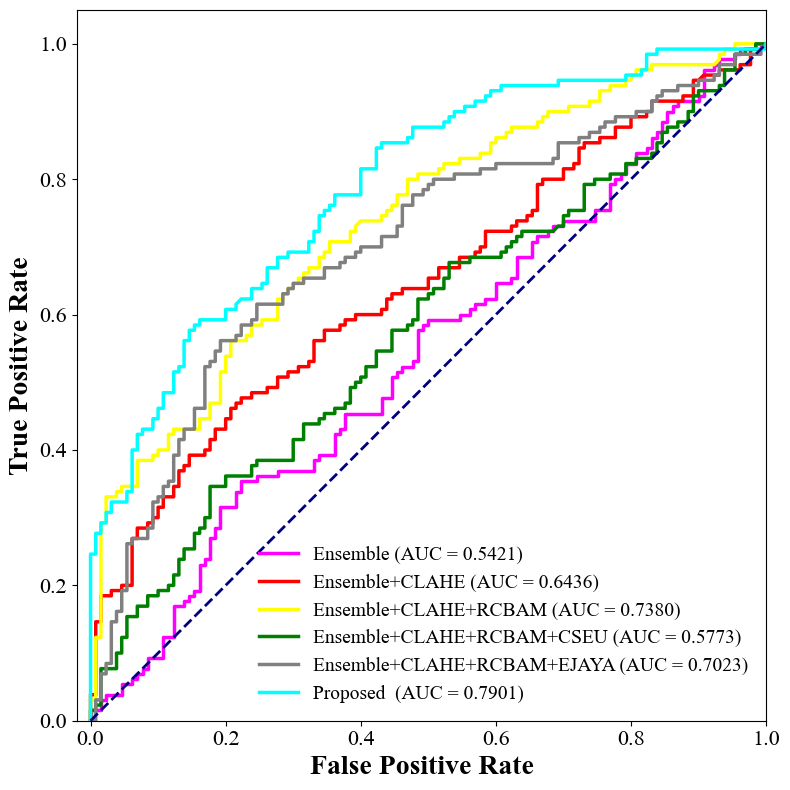

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

# ==========================================
# 1. Configuration & Paths
# ==========================================
# Directory where all your prediction_details CSVs are stored
DATA_DIR = r"D:\My Research\ALL\image\test" 
output_dir = r"D:\My Research\ALL\image"
output_filename = "roc.png"
output_path = os.path.join(output_dir, output_filename)

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 2. Font & Style Setup (Research Quality)
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'
TITLE_FONT_SIZE = 24
LABEL_FONT_SIZE = 20
TICK_FONT_SIZE = 16
LEGEND_FONT_SIZE = 14 # Slightly smaller to fit multiple models

# ==========================================
# 3. Define Models, Files & Colors
# ==========================================
# Map each model to its specific file and line color
model_config = {
    "Ensemble":                   {"file": "fusion_mobilenet_resnet_prediction_details.csv", "color": "magenta"},
    "Ensemble+CLAHE":             {"file": "fusion_mobilenet_resnet_clahe_prediction_details.csv", "color": "red"},
    "Ensemble+CLAHE+RCBAM":        {"file": "fusion_mobilenet_resnet_clahe_rcbam_prediction_details.csv", "color": "yellow"},
    "Ensemble+CLAHE+RCBAM+CSEU":   {"file": "fusion_mobilenet_resnet_clahe_rcbam_cseu_prediction_details.csv", "color": "green"},
    "Ensemble+CLAHE+RCBAM+EJAYA":  {"file": "fusion_mobilenet_resnet_clahe_rcbam_ejaya_prediction_details.csv", "color": "gray"},
    "Proposed ":             {"file": "fusion_mobilenet_resnet_full_proposed_prediction_details.csv", "color": "cyan"}
}

# ==========================================
# 4. Data Processing & Plotting
# ==========================================
plt.figure(figsize=(8, 8)) # Made slightly larger to accommodate a bigger legend

# Loop through each model in the config
for model_name, config in model_config.items():
    file_path = os.path.join(DATA_DIR, config["file"])
    
    if not os.path.exists(file_path):
        print(f"Warning: File not found -> {file_path}")
        continue

    # Load Data
    df = pd.read_csv(file_path)

    # Convert string labels to binary classes 
    # 'cancer' becomes 1 (positive class), 'non cancer' becomes 0
    y_true = df['True Label'].apply(lambda x: 1 if str(x).strip().lower() == 'cancer' else 0)

    # The model's predicted probability for the positive class
    y_scores = df['Prob_cancer']

    # Compute False Positive Rate (FPR), True Positive Rate (TPR), and Area Under Curve (AUC)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for this model
    plt.plot(fpr, tpr, color=config["color"], lw=2.5, 
             label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot the baseline random guess dashed line (Navy blue)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set axis limits
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])

# Apply labels and titles with manual sizing and bold weights
plt.xlabel('False Positive Rate', fontsize=LABEL_FONT_SIZE, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=LABEL_FONT_SIZE, fontweight='bold')
# plt.title('ROC Curve', fontsize=TITLE_FONT_SIZE, fontweight='bold', pad=15)

# Style ticks
plt.xticks(fontsize=TICK_FONT_SIZE)
plt.yticks(fontsize=TICK_FONT_SIZE)

# Place the legend in the bottom right corner without a frame box
plt.legend(loc="lower right", fontsize=LEGEND_FONT_SIZE, frameon=False)

# ==========================================
# 5. Save & Display
# ==========================================
plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Success! ROC Curve saved to: {output_path}")

plt.show()

Success! Precision-Recall Curve saved to: D:\My Research\ALL\image\precision_recall.png


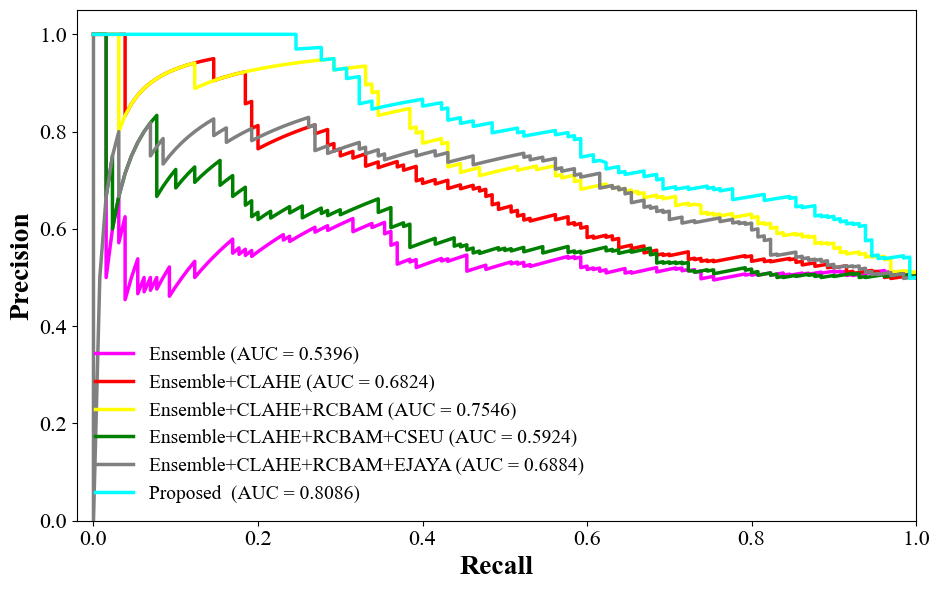

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import os

# ==========================================
# 1. Configuration & Paths
# ==========================================
# Directory where all your prediction_details CSVs are stored
DATA_DIR = r"D:\My Research\ALL\image\test" 
output_dir = r"D:\My Research\ALL\image"
output_filename = "precision_recall.png"
output_path = os.path.join(output_dir, output_filename)

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 2. Font & Style Setup (Research Quality)
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'
TITLE_FONT_SIZE = 24
LABEL_FONT_SIZE = 20
TICK_FONT_SIZE = 16
LEGEND_FONT_SIZE = 14 # Slightly smaller to fit multiple models

# ==========================================
# 3. Define Models, Files & Colors
# ==========================================
# Map each model to its specific file and line color
model_config = {
    "Ensemble":                   {"file": "fusion_mobilenet_resnet_prediction_details.csv", "color": "magenta"},
    "Ensemble+CLAHE":             {"file": "fusion_mobilenet_resnet_clahe_prediction_details.csv", "color": "red"},
    "Ensemble+CLAHE+RCBAM":        {"file": "fusion_mobilenet_resnet_clahe_rcbam_prediction_details.csv", "color": "yellow"},
    "Ensemble+CLAHE+RCBAM+CSEU":   {"file": "fusion_mobilenet_resnet_clahe_rcbam_cseu_prediction_details.csv", "color": "green"},
    "Ensemble+CLAHE+RCBAM+EJAYA":  {"file": "fusion_mobilenet_resnet_clahe_rcbam_ejaya_prediction_details.csv", "color": "gray"},
    "Proposed ":             {"file": "fusion_mobilenet_resnet_full_proposed_prediction_details.csv", "color": "cyan"}
}
# ==========================================
# 4. Data Processing & Plotting
# ==========================================
plt.figure(figsize=(9.5, 6)) # Made slightly larger to accommodate a bigger legend

# Loop through each model in the config
for model_name, config in model_config.items():
    file_path = os.path.join(DATA_DIR, config["file"])
    
    if not os.path.exists(file_path):
        print(f"Warning: File not found -> {file_path}")
        continue

    # Load Data
    df = pd.read_csv(file_path)

    # Convert string labels to binary classes 
    # 'cancer' becomes 1 (positive class), 'non cancer' becomes 0
    y_true = df['True Label'].apply(lambda x: 1 if str(x).strip().lower() == 'cancer' else 0)

    # The model's predicted probability for the positive class
    y_scores = df['Prob_cancer']

    # Compute Precision, Recall, and Area Under the PR Curve (PR-AUC)
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)

    # Plot the PR curve for this model
    plt.plot(recall, precision, color=config["color"], lw=2.5, 
             label=f'{model_name} (AUC = {pr_auc:.4f})')

# Set axis limits
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])

# Apply labels and titles with manual sizing and bold weights
plt.xlabel('Recall', fontsize=LABEL_FONT_SIZE, fontweight='bold')
plt.ylabel('Precision', fontsize=LABEL_FONT_SIZE, fontweight='bold')
# plt.title('Precision-Recall Curve', fontsize=TITLE_FONT_SIZE, fontweight='bold', pad=15)

# Style ticks
plt.xticks(fontsize=TICK_FONT_SIZE)
plt.yticks(fontsize=TICK_FONT_SIZE)

# Place the legend in the bottom left corner for PR curves
plt.legend(loc="lower left", fontsize=LEGEND_FONT_SIZE, frameon=False)

# ==========================================
# 5. Save & Display
# ==========================================
plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Success! Precision-Recall Curve saved to: {output_path}")

plt.show()

Generating graph with Times New Roman font...
Graph saved: D:\My Research\ALL\image\loss.png


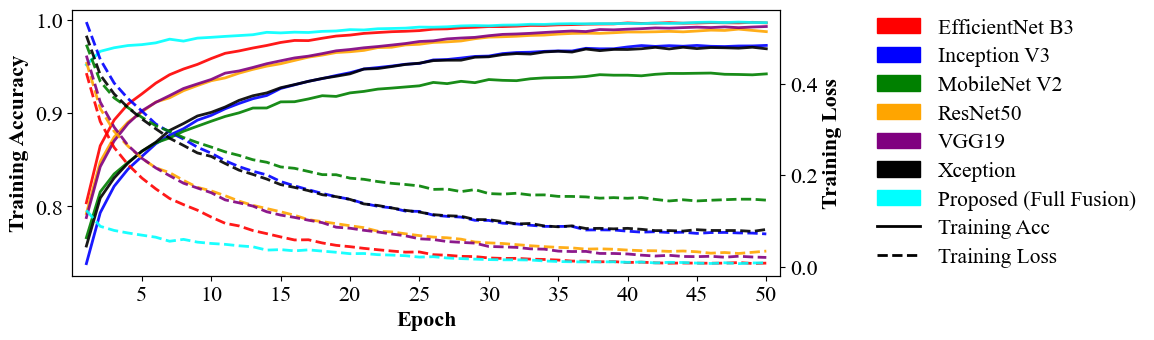

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import os

# ==========================================
# --- 0. FONT SETUP ---
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'

# ==========================================
# --- 1. CONFIGURATION ---
# ==========================================
DATA_PATH = r'D:\My Research\ALL\image\training'
OUTPUT_PATH = r'D:\My Research\ALL\image'

# --- MANUAL LEGEND BOX CONTROL ---
BOX_X = 1.11       
BOX_Y = 0.5        
LEGEND_FONT_SIZE = 15.5

# --- MANUAL AXIS CONTROL ---
FIG_WIDTH = 12     
FIG_HEIGHT = 3.5   

# --- Edit sizes here ---
AXIS_LABEL_SIZE = 16  
TICK_LABEL_SIZE = 16  

# 3. Axis Limits (Set MAX to 50 as requested)
MANUAL_X_MAX = 50       
MANUAL_Y_ACC_LIM = None   
MANUAL_Y_LOSS_LIM = None  

os.makedirs(OUTPUT_PATH, exist_ok=True)

# ==========================================
# --- 2. DEFINE MODEL FILES & UNIQUE COLORS ---
# ==========================================
# Updated to ensure NO repeated colors across all 12 models
model_config = {
    "EfficientNet B3":                    {"file": "efficientnetB3_training_history_all.csv", "color": "red"},
    "Inception V3":                       {"file": "inceptionv3_training_history_all.csv", "color": "blue"},
    "MobileNet V2":                       {"file": "mobilenetv2_training_history_all.csv", "color": "green"},
    "ResNet50":                           {"file": "resnet50_training_history_all.csv", "color": "orange"},
    "VGG19":                              {"file": "vgg19_training_history_all.csv", "color": "purple"},
    "Xception":                           {"file": "xception_training_history_all.csv", "color": "black"},
    # "MobileNet+ResNet":                   {"file": "fusion_mobilenet_resnet_clahe_training_history_all.csv", "color": "magenta"},
    # "MobileNet+ResNet+CLAHE":             {"file": "fusion_mobilenet_resnet_clahe_training_history_all.csv", "color": "brown"},
    # "MobileNet+ResNet+CLAHE+RCAM":        {"file": "fusion_mobilenet_resnet_clahe_rcbam_training_history_all.csv", "color": "pink"},
    # "MobileNet+ResNet+CLAHE+RCAM+CSEU":   {"file": "fusion_mobilenet_resnet_clahe_rcbam_cseu_training_history_all.csv", "color": "olive"},
    # "MobileNet+ResNet+CLAHE+RCAM+EJAYA":  {"file": "fusion_mobilenet_resnet_clahe_rcbam_ejaya_training_history_all.csv", "color": "gray"},
    "Proposed (Full Fusion)":             {"file": "fusion_mobilenet_resnet_full_proposed_training_history_all.csv", "color": "cyan"}
}

def plot_custom_legend_graph(data_dir, output_dir):
    model_data = {}

    # --- 3. Load Data ---
    for model_name, config in model_config.items():
        full_path = os.path.join(data_dir, config["file"])
        if not os.path.exists(full_path):
            print(f"Skipping {model_name}: File not found at {full_path}")
            continue
            
        df = pd.read_csv(full_path)
        
        # Standardize the epoch column name to capitalize 'Epoch'
        df.columns = [col.capitalize() if col.lower() == 'epoch' else col for col in df.columns]
        
        # Group by 'Epoch' and average the folds
        df_avg = df.groupby('Epoch').mean(numeric_only=True).reset_index()
        model_data[model_name] = df_avg

    # --- 4. Setup Plot ---
    fig, ax1 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
    ax2 = ax1.twinx()  
    
    # --- 5. Plot Lines ---
    max_data_epoch = 0
    for model_name, df_avg in model_data.items():
        color = model_config[model_name]["color"]
        if not df_avg.empty:
            max_data_epoch = max(max_data_epoch, df_avg['Epoch'].max())

            acc_col = None
            loss_col = None
            
            # Safely find the Accuracy and Loss columns dynamically
            for col in df_avg.columns:
                col_lower = col.lower()
                if 'train_acc' in col_lower or 'train acc' in col_lower or ('acc' in col_lower and 'train' in col_lower):
                    acc_col = col
                if 'train_loss' in col_lower or 'train loss' in col_lower or ('loss' in col_lower and 'train' in col_lower):
                    loss_col = col

            if acc_col and loss_col:
                ax1.plot(df_avg['Epoch'], df_avg[acc_col], 
                         color=color, linestyle='-', linewidth=2, alpha=0.9)
                
                ax2.plot(df_avg['Epoch'], df_avg[loss_col], 
                         color=color, linestyle='--', linewidth=2, alpha=0.9)
            else:
                print(f"Warning: Could not find Train Acc or Train Loss in {model_name}. Available columns: {list(df_avg.columns)}")

    # --- 6. Format Axes ---
    ax1.set_xlabel('Epoch', fontsize=AXIS_LABEL_SIZE , fontweight='bold')
    ax1.set_ylabel('Training Accuracy', fontsize=AXIS_LABEL_SIZE, fontweight='bold')
    ax2.set_ylabel('Training Loss', fontsize=AXIS_LABEL_SIZE, fontweight='bold')

    # Apply tick label sizes
    ax1.tick_params(axis='both', which='major', labelsize=TICK_LABEL_SIZE)
    ax2.tick_params(axis='both', which='major', labelsize=TICK_LABEL_SIZE)

    # Manual Limits Logic
    final_max_epoch = MANUAL_X_MAX if MANUAL_X_MAX else max(50, int(max_data_epoch))
    
    # Updated: Set X-axis ticks to 5, 10, 15, ..., 50
    ax1.set_xticks(range(5, final_max_epoch + 1, 5))
    ax1.set_xlim(0, final_max_epoch + 1)

    if MANUAL_Y_ACC_LIM:
        ax1.set_ylim(MANUAL_Y_ACC_LIM)
    
    if MANUAL_Y_LOSS_LIM:
        ax2.set_ylim(MANUAL_Y_LOSS_LIM)

    # ax1.grid(True, linestyle=':', alpha=0.6)

    # --- 7. BUILD CUSTOM LEGEND ---
    legend_handles = []

    for model_name, config in model_config.items():
        if model_name in model_data:
            patch = mpatches.Patch(color=config["color"], label=model_name)
            legend_handles.append(patch)

    acc_line = mlines.Line2D([], [], color='black', linestyle='-', linewidth=2, label='Training Acc')
    legend_handles.append(acc_line)

    loss_line = mlines.Line2D([], [], color='black', linestyle='--', linewidth=2, label='Training Loss')
    legend_handles.append(loss_line)

    ax1.legend(handles=legend_handles, 
               loc='center left', 
               bbox_to_anchor=(BOX_X, BOX_Y),
               fontsize=LEGEND_FONT_SIZE,
               title_fontsize=LEGEND_FONT_SIZE+1,
               labelspacing=0.4,
               frameon=False) 

    # --- 8. Save & Show ---
    plt.tight_layout()
    save_file = os.path.join(output_dir, 'loss.png')
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    print(f"Graph saved: {save_file}")
    plt.show()

# --- Main Execution ---
print("Generating graph with Times New Roman font...")
plot_custom_legend_graph(DATA_PATH, OUTPUT_PATH)

Graph saved: D:\My Research\FINISHED\soybean_jorunal2\image\result\Spider.png


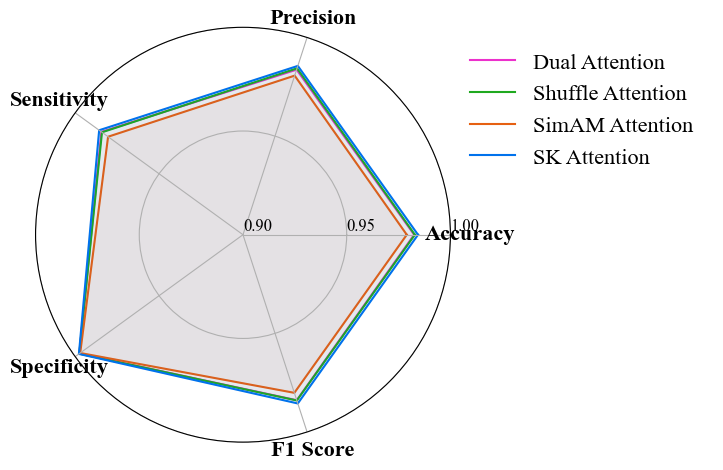

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import os

# ==========================================
# --- 0. FONT SETUP ---
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16

# ==========================================
# --- 1. CONFIGURATION ---
# ==========================================
DATA_PATH = r'D:\My Research\FINISHED\soybean_jorunal2\image\result'

# --- MANUAL LEGEND CONTROL ---
LEGEND_FONT_SIZE = 16 

# Adjust these values to manually move the legend
LEGEND_X = 1           # 1.0 is the right edge of the plot. Increase to move further right.
LEGEND_Y = 0.8         # 0.5 is vertically centered. 1.0 is top, 0.0 is bottom.
LEGEND_LOC = 'center left' # Which corner of the legend box to pin to the X/Y coordinates

# Define the file mapping
model_map = {
    
    "Dual Attention": {"file": "efficientnet_v2_s_dual_att_results.csv", "color": "pink"},
    "Shuffle Attention": {"file": "efficientnet_v2_s_shuffle_att_results.csv", "color": "cyan"},
    "SimAM Attention  ": {"file": "efficientnet_v2_s_simam_results.csv", "color": "green"},
    "SK Attention": {"file": "efficientnet_v2_s_sknet_results.csv", "color": "red"},

}

# Define metrics (Make sure your CSV column headers match these EXACTLY)
metrics = ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score']

# Define colors
colors = ["#ec31cc", "#1fa91f","#e66012", "#0072ec", "#ff0000"]  # Updated color palette

# ==========================================
# --- 2. PROCESS DATA ---
# ==========================================
data_means = {}

# FIXED: Changed 'filename' to 'model_info' to reflect that it's a dictionary
for label, model_info in model_map.items():
    filename = model_info["file"] # Extracted the actual string here
    path = os.path.join(DATA_PATH, filename)
    
    if os.path.exists(path):
        df = pd.read_csv(path)
        # Calculate means
        means = [df[m].mean() for m in metrics]
        data_means[label] = means
    else:
        print(f"Warning: {filename} not found in {DATA_PATH}.")

# ==========================================
# --- 3. PLOT ---
# ==========================================
if data_means:
    N = len(metrics)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 5), subplot_kw={'projection': 'polar'})

    # Axis labels
    plt.xticks(angles[:-1], metrics, color='black', size=16, weight='bold')

    # Y-axis Scale Control
    ax.set_rlabel_position(0)

    # Set manual limits and ticks as requested: 0.90, 0.95, 1.0
    ax.set_ylim(0.90, 1.0)
    ax.set_yticks([0.90, 0.95, 1.0])
    ax.set_yticklabels(["0.90", "0.95", "1.00"], fontsize=12)

    # Plotting
    color_idx = 0
    for label, values in data_means.items():
        # Create a new list rather than modifying in-place to avoid duplication bugs if re-run
        plot_values = values + values[:1] 
        
        if label == "Proposed":
            lw = 1.5
            ls = 'solid'
            col = '#1cbcec'  # Cyan for Proposed
            zorder = 10
        else:
            lw = 1.5
            ls = 'solid' 
            col = colors[color_idx % len(colors)]
            color_idx += 1
            zorder = 1
            
        ax.plot(angles, plot_values, linewidth=lw, linestyle=ls, label=label, color=col, zorder=zorder)
        # Fill area slightly
        ax.fill(angles, plot_values, color=col, alpha=0.05)

    # Legend
    plt.legend(loc=LEGEND_LOC, bbox_to_anchor=(LEGEND_X, LEGEND_Y), fontsize=LEGEND_FONT_SIZE, frameon=False)

    plt.tight_layout()
    save_file = os.path.join(DATA_PATH, 'Spider.png')
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    print(f"Graph saved: {save_file}")
    plt.show()
else:
    print("No data found, please check your path.")

C:\Users\beeza\AppData\Local\Temp\ipykernel_23140\807625545.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(values_to_plot,


Graph saved: D:\My Research\soybean_jorunal2\image\result\modify\BoxPlot.png


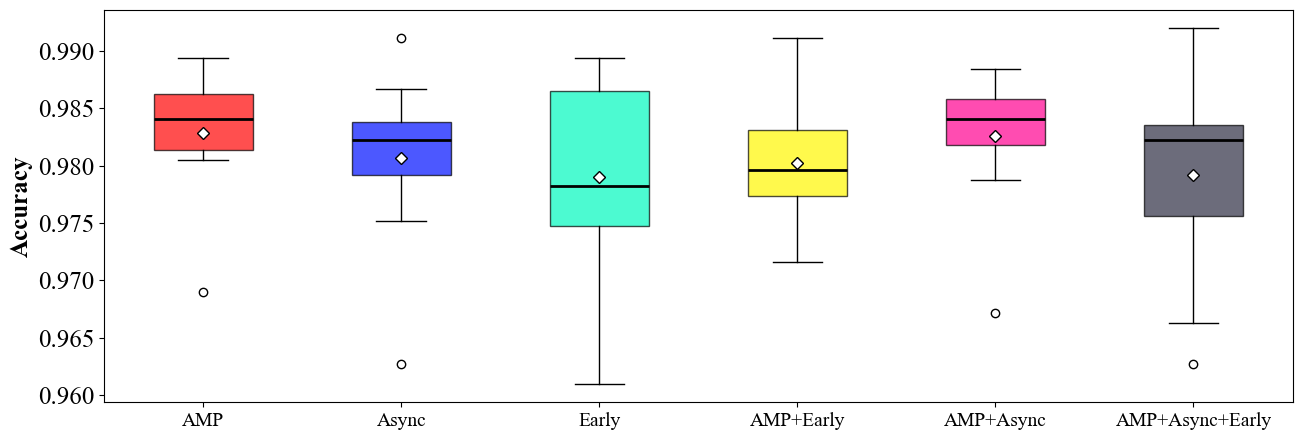

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# --- 0. FONT SETUP ---
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10

# ==========================================
# --- 1. CONFIGURATION ---
# ==========================================
DATA_PATH = r'D:\My Research\soybean_jorunal2\image\result\modify'

# Define the file mapping
model_map = {
    "AMP": "amp_efficientnet_v2_s_results.csv",
    "Async": "asyn_efficientnet_v2_s_results.csv",
    "Early": "early_efficientnet_v2_s_results.csv",
    "AMP+Early": "amp+early_efficientnet_v2_s_results.csv",
    "AMP+Async": "amp+asyn_efficientnet_v2_s_results.csv",
    "AMP+Async+Early": "amp+asyn+early_efficientnet_v2_s_results.csv"
}

# Define Colors for each model
model_colors = {
    "AMP": "#ff0505",       # Blue
    "Async": "#0011ff",       # Orange
    "Early": "#00f8be",       # Green
    "AMP+Early": "#fff700",    # Purple
    "AMP+Async": "#FF0090", # Gray
    "AMP+Async+Early": "#2e2e43"        # Red
}

# ==========================================
# --- 2. LOAD DATA ---
# ==========================================
model_names = list(model_map.keys())
model_data = {} 

for name in model_names:
    filename = model_map[name]
    path = os.path.join(DATA_PATH, filename)
    
    if os.path.exists(path):
        df = pd.read_csv(path)
        model_data[name] = df
    else:
        print(f"Warning: {filename} not found.")
        model_data[name] = None

# ==========================================
# --- 3. PLOT ---
# ==========================================
# Only proceed if we have data
if any(v is not None for v in model_data.values()):
    fig, ax = plt.subplots(figsize=(13, 4.5))

    # Style props
    medianprops = dict(linestyle='-', linewidth=2, color='black')
    meanprops = dict(marker='D', markeredgecolor='black', markerfacecolor='white')

    values_to_plot = []
    current_labels = []

    # Collect data for Accuracy
    for name in model_names:
        if model_data[name] is not None:
            values_to_plot.append(model_data[name]["Accuracy"].values)
            current_labels.append(name)

    # Create boxplot
    bplot = ax.boxplot(values_to_plot, 
                       labels=current_labels, 
                       patch_artist=True,
                       showmeans=True,
                       medianprops=medianprops,
                       meanprops=meanprops)

    # Apply individual colors
    for patch, label in zip(bplot['boxes'], current_labels):
        patch.set_facecolor(model_colors[label])
        patch.set_alpha(0.7)

    # Formatting
    ax.set_ylabel("Accuracy", weight='bold', fontsize=18)
    ax.tick_params(axis='x', rotation=0, labelsize=14)
    ax.tick_params(axis='y', labelsize=18)

    plt.tight_layout()
    save_file = os.path.join(DATA_PATH, 'BoxPlot.png')
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    print(f"Graph saved: {save_file}")
    plt.show()
else:
    print("No data found to plot.")

Success! The confusion matrix has been saved to: D:\My Research\ALL\image\confusion.png


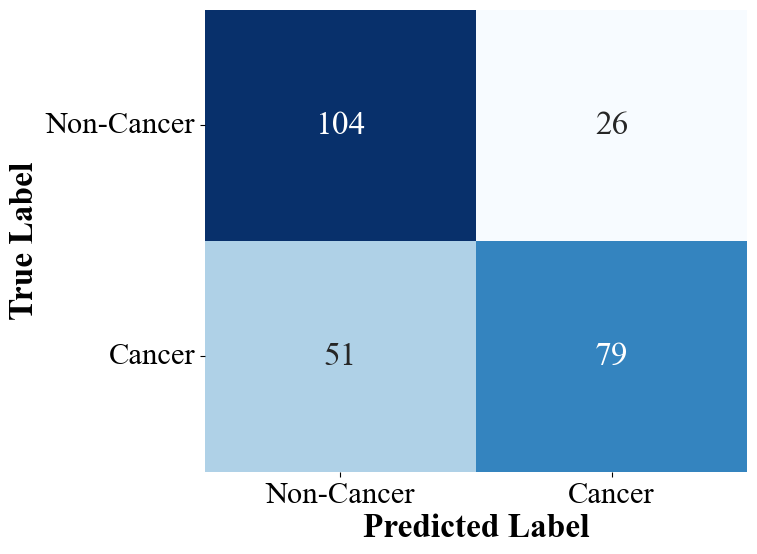

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# ==========================================
# 1. Path Configurations
# ==========================================
# Update this path to where your new file is located
input_csv = "D:\\My Research\\ALL\\test\\test_results\\fusion_mobilenet_resnet_full_proposed\\prediction_details.csv" 
output_dir = "D:\\My Research\\ALL\\image"
output_filename = "confusion.png"
output_path = os.path.join(output_dir, output_filename)

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 2. Font & Style Configurations (Manual)
# ==========================================
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Manual font sizes for easy adjustment
TITLE_FONT_SIZE = 28
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 22
ANNOT_FONT_SIZE = 24  # Size for the numbers inside the matrix boxes

# ==========================================
# 3. Data Loading & Processing
# ==========================================
# Load the raw prediction details
df = pd.read_csv(input_csv)

# Define the exact labels as they appear in the CSV's "True Label" column
data_labels = ['non cancer', 'cancer']
# Define the custom labels for the graph presentation
display_labels = ['Non-Cancer', 'Cancer']

# Compute the confusion matrix dynamically from the raw rows
cm = confusion_matrix(df['True Label'], df['Predicted Label'], labels=data_labels)

# Convert to DataFrame to maintain compatibility with your original seaborn setup
cm_df = pd.DataFrame(cm, index=display_labels, columns=display_labels)

# ==========================================
# 4. Plotting
# ==========================================
plt.figure(figsize=(7, 6))

# Create the heatmap using seaborn
sns.heatmap(
    cm_df, 
    annot=True,                 # Show the numbers inside the cells
    fmt='d',                    # Format as integers
    cmap='Blues',               # Colormap 
    cbar=False,                 # Removed color bar
    annot_kws={"size": ANNOT_FONT_SIZE} # Apply manual font size to numbers
)

# Apply manual font sizes to title and axis labels
plt.xlabel('Predicted Label', fontsize=LABEL_FONT_SIZE, fontweight='bold')
plt.ylabel('True Label', fontsize=LABEL_FONT_SIZE, fontweight='bold')

# Apply manual font sizes to ticks and rotate y-axis labels for readability
plt.xticks(fontsize=TICK_FONT_SIZE)
plt.yticks(fontsize=TICK_FONT_SIZE, rotation=0) 

# ==========================================
# 5. Saving and Displaying
# ==========================================
# Save the plot with 300 DPI for high-quality research publication
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Success! The confusion matrix has been saved to: {output_path}")

plt.show()


Success! Chart saved to: D:\My Research\soybean_jorunal2\image\bar_chart.png


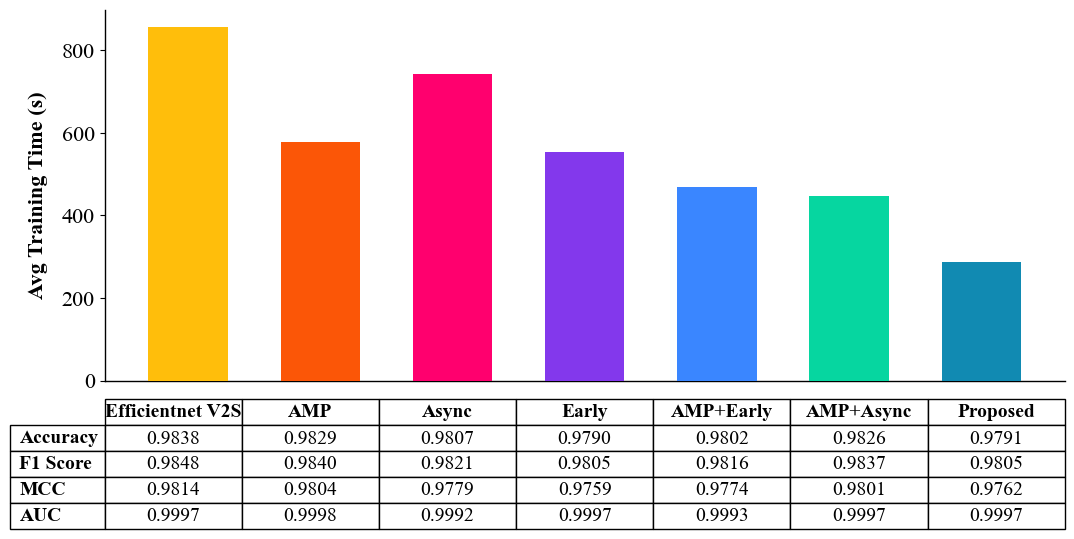

In [ ]:
eecommu06@eecommu06-ROG-Strix-GA35DX:~/Desktop/Bee/breast_cancer$ /bin/python3 /home/eecommu06/Desktop/Bee/breast_cancer/model/test/test_convnext_tiny.py
Device: cuda

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
! WARNING: --data_dir looks like CBIS-DDSM, the DEVELOPMENT dataset.
! The checkpoint was trained with 10-fold CV over these images, so
! almost every image here was seen during training. Metrics will be
! OPTIMISTIC and are NOT valid external test results.
! For the manuscript's external test, point --data_dir at CMMD.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

  Benign                                        -> benign    (1728 images)
  Malignant                                     -> malignant (1375 images)
Images: 3103 | benign=1728 malignant=1375 | patient ids parsed: 1566
Traceback (most recent call last):
  File "/home/eecommu06/Desktop/Bee/breast_cancer/model/test/test_convnext_tiny.py", line 513, in <module>
    main()
  File "/home/eecommu06/Desktop/Bee/breast_cancer/model/test/test_convnext_tiny.py", line 387, in main
    model, meta = load_checkpoint(model, args.ckpt, device)
  File "/home/eecommu06/Desktop/Bee/breast_cancer/model/test/test_convnext_tiny.py", line 234, in load_checkpoint
    ckpt = torch.load(ckpt_path, map_location=device)
  File "/home/eecommu06/.local/lib/python3.10/site-packages/torch/serialization.py", line 1529, in load
    raise pickle.UnpicklingError(_get_wo_message(str(e))) from None
_pickle.UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
        (1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
        (2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
        WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.